# $B_s^0 \to K^{*0}\bar{K}^{*0} \to K^+\pi^-K^-\pi^+$ Experiment Analysis

**Name:** Baiyuan Chen

**CRSID:** bc654

*(Below, "we" is used instead of "I" to follow the convention of scientific writing.)*

Code for Q2 sections 2–5 of the experiment coursework.

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

data_path = "../../data/data.root"
mc_path = "../../data/mc.root"

data_tree = uproot.open(f"{data_path}:DecayTree")
mc_tree = uproot.open(f"{mc_path}:DecayTree")

print(f"Data entries: {data_tree.num_entries:,}")
print(f"MC entries:   {mc_tree.num_entries:,}")

Data entries: 939,429
MC entries:   5,357,612


# Section 2: Reducing Combinatorial Background

## 2.1 Signal and background samples

- **Signal**: MC simulation (`mc.root`) — true $B_s^0 \to K^{*0}\bar{K}^{*0}$ decays
- **Background**: data sideband $m_{B_s} > 5600\;\text{MeV}/c^2$ — combinatorial background from random track combinations

**Excluded features:**
- **Mass variables** ($m_{B_s}$, $K^*$ masses, pion masses): these are excluded to prevent the classifier from learning quantities that will later be used in the mass fit or selection. Including them would distort the mass distribution and introduce bias in the fit.
- **Vertex XYZ coordinates**: these depend on the detector geometry and are not Lorentz invariant. Differences between simulation and data, arising from variations in the beam spot and run conditions, could lead the BDT to learn non physical distinctions rather than genuine physics features.

In [2]:
# Define background: data sideband Bs_M > 5600 MeV
data_Bs_M = data_tree.arrays(["Bs_M"], library="np")["Bs_M"]
bkg_idx = np.where(data_Bs_M > 5600)[0]
print(f"Background (Bs_M > 5600): {len(bkg_idx):,} events")

# Common branches, excluding mass variables and XYZ vertex/position features
common_branches = sorted(set(data_tree.keys()) & set(mc_tree.keys()))
exclude = {"Bs_M", "Bs_Kst_M", "Bs_Kstb_M", "pip_M", "pim_M", "Kst_M", "Kstb_M"}
vertex_tags = ("Vertex_X", "Vertex_Y", "Vertex_Z")
feature_cols = [c for c in common_branches
                if c not in exclude and not any(c.endswith(tag) for tag in vertex_tags)]
print(f"Candidate features: {len(feature_cols)}")

Background (Bs_M > 5600): 149,031 events
Candidate features: 97


## 2.2 Feature ranking (KS test)

Rank all features by two-sample Kolmogorov–Smirnov statistic between signal (MC) and background (data sideband). Larger KS $\Rightarrow$ better separation.

In [3]:
# Compute KS statistic for each feature: MC (signal) vs data sideband (background)
# Downsample MC to 200k for speed
n_ks_sample = 200000
sig_ks_dict = mc_tree.arrays(feature_cols, library="np", entry_stop=n_ks_sample)

ks_results = []
for col in feature_cols:
    s = sig_ks_dict[col]
    b = data_tree.arrays([col], library="np")[col][bkg_idx]
    ks_stat, ks_pval = stats.ks_2samp(s, b)
    ks_results.append((col, ks_stat, ks_pval))

del sig_ks_dict
ks_results.sort(key=lambda x: -x[1])

# Display
print(f"{'Rank':<5} {'Feature':<40} {'KS stat':>10} {'p-value':>12}")
print("-" * 70)
for i, (col, ks, pv) in enumerate(ks_results):
    marker = " <--" if i < 20 else ""
    print(f"{i+1:<5} {col:<40} {ks:>10.4f} {pv:>12.2e}{marker}")

Rank  Feature                                     KS stat      p-value
----------------------------------------------------------------------
1     Bs_CosMomentumDecayAngle                     0.7865     0.00e+00 <--
2     Bs_FlightDistance_Chi2                       0.7116     0.00e+00 <--
3     Kstb_ImpactParameter_Chi2                    0.6614     0.00e+00 <--
4     Kst_ImpactParameter_Chi2                     0.6600     0.00e+00 <--
5     Bs_DecayLength                               0.6585     0.00e+00 <--
6     Bs_FlightDistance                            0.6520     0.00e+00 <--
7     Km_ImpactParameter_Chi2                      0.6324     0.00e+00 <--
8     Kp_ImpactParameter_Chi2                      0.6312     0.00e+00 <--
9     Bs_DecayTime                                 0.6038     0.00e+00 <--
10    pip_ImpactParameter_Chi2                     0.5766     0.00e+00 <--
11    pim_ImpactParameter_Chi2                     0.5757     0.00e+00 <--
12    Bs_ImpactParameter         

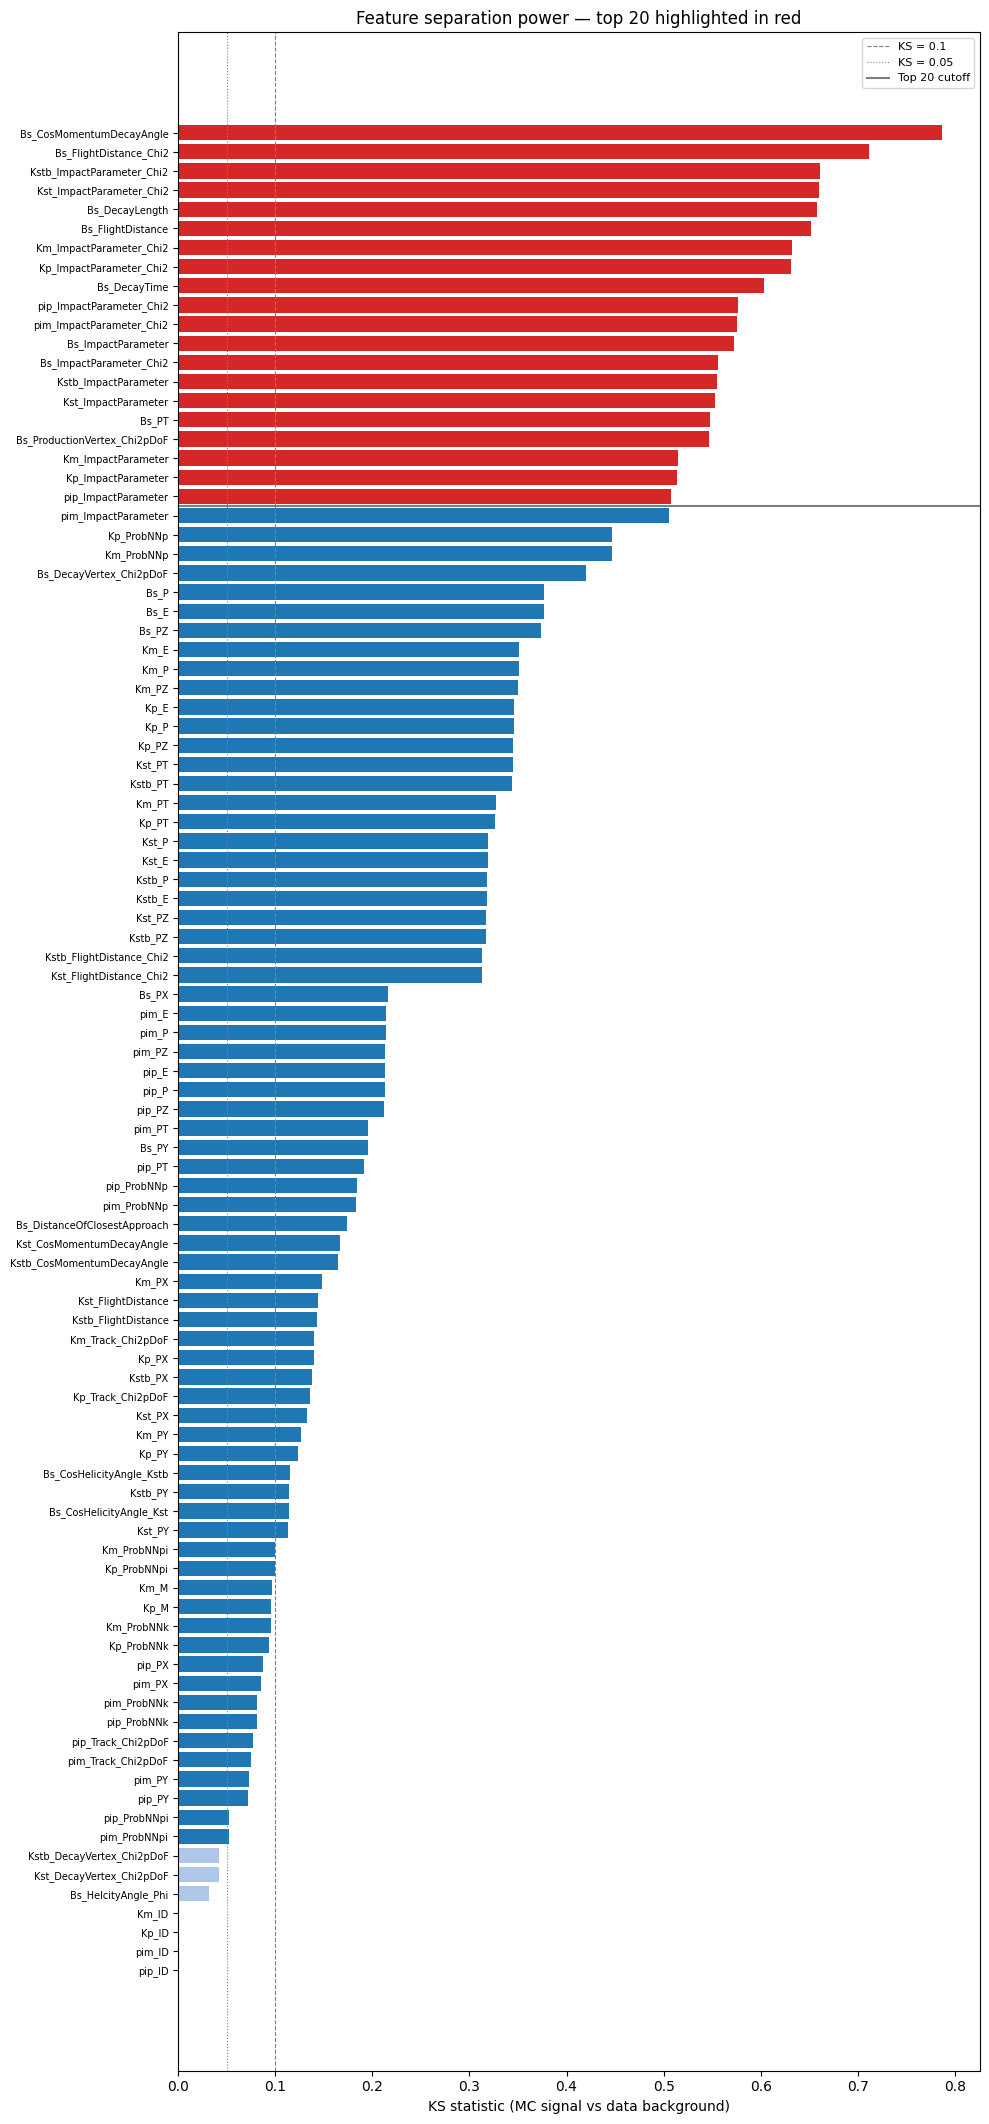

In [4]:
# Plot KS statistics
fig, ax = plt.subplots(figsize=(10, max(6, len(ks_results) * 0.22)))
names = [r[0] for r in ks_results]
vals = [r[1] for r in ks_results]
colors = ["#d62728" if i < 20 else "#1f77b4" if ks > 0.05 else "#aec7e8"
          for i, ks in enumerate(vals)]
ax.barh(range(len(names)), vals, color=colors)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=7)
ax.set_xlabel("KS statistic (MC signal vs data background)")
ax.set_title("Feature separation power — top 20 highlighted in red")
ax.invert_yaxis()
ax.axvline(0.1, color="gray", ls="--", lw=0.8, label="KS = 0.1")
ax.axvline(0.05, color="gray", ls=":", lw=0.8, label="KS = 0.05")
# Mark the cutoff
ax.axhline(19.5, color="black", ls="-", lw=1.5, alpha=0.5, label="Top 20 cutoff")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2.3 Feature selection and training data

Select the top 20 features by KS statistic. Downsample MC to balance class sizes, then split 70/30 into train/test sets.

In [5]:
# Select the top 20 features by KS statistic
top20 = [col for col, _, _ in ks_results[:20]]
print("Top 20 features for classifier:")
for i, f in enumerate(top20):
    ks = ks_results[i][1]
    print(f"  {i+1:2d}. {f:<40s} KS = {ks:.4f}")

Top 20 features for classifier:
   1. Bs_CosMomentumDecayAngle                 KS = 0.7865
   2. Bs_FlightDistance_Chi2                   KS = 0.7116
   3. Kstb_ImpactParameter_Chi2                KS = 0.6614
   4. Kst_ImpactParameter_Chi2                 KS = 0.6600
   5. Bs_DecayLength                           KS = 0.6585
   6. Bs_FlightDistance                        KS = 0.6520
   7. Km_ImpactParameter_Chi2                  KS = 0.6324
   8. Kp_ImpactParameter_Chi2                  KS = 0.6312
   9. Bs_DecayTime                             KS = 0.6038
  10. pip_ImpactParameter_Chi2                 KS = 0.5766
  11. pim_ImpactParameter_Chi2                 KS = 0.5757
  12. Bs_ImpactParameter                       KS = 0.5728
  13. Bs_ImpactParameter_Chi2                  KS = 0.5557
  14. Kstb_ImpactParameter                     KS = 0.5554
  15. Kst_ImpactParameter                      KS = 0.5530
  16. Bs_PT                                    KS = 0.5477
  17. Bs_ProductionVerte

In [ ]:
# Load signal (MC) and background (data sideband) for the top 20 features
# Downsample MC to match background size order-of-magnitude for balanced training
n_sig_use = 150000  # subsample MC for tractable training

sig_dict = mc_tree.arrays(top20, library="np", entry_stop=n_sig_use)
X_sig = np.column_stack([sig_dict[col] for col in top20])
del sig_dict

bkg_dict = {col: data_tree.arrays([col], library="np")[col][bkg_idx] for col in top20}
X_bkg = np.column_stack([bkg_dict[col] for col in top20])
del bkg_dict

print(f"Signal samples:     {X_sig.shape[0]:,}  ({X_sig.shape[1]} features)")
print(f"Background samples: {X_bkg.shape[0]:,}  ({X_bkg.shape[1]} features)")

# Load MC weights alongside features
mc_weights = mc_tree.arrays(["weight"], library="np", entry_stop=n_sig_use)["weight"]

# Combine and label: signal=1, background=0
X = np.vstack([X_sig, X_bkg])
y = np.concatenate([np.ones(len(X_sig)), np.zeros(len(X_bkg))])
w = np.concatenate([mc_weights, np.ones(len(X_bkg))])

# Train/test split (50/50)
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.5, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train):,}  (sig: {int(y_train.sum()):,}, bkg: {int((1-y_train).sum()):,})")
print(f"Test set:     {len(X_test):,}  (sig: {int(y_test.sum()):,}, bkg: {int((1-y_test).sum()):,})")

Signal samples:     150,000  (20 features)
Background samples: 149,031  (20 features)

Training set: 149,515  (sig: 75,000, bkg: 74,515)
Test set:     149,516  (sig: 75,000, bkg: 74,516)


## 2.4 Train XGBoost BDT

Shallow trees (`max_depth=2`) with `min_child_weight=100` to limit overtraining. 400 boosting rounds with early stopping.

In [ ]:
# Train an XGBoost BDT
bdt = XGBClassifier(
    n_estimators=400,
    max_depth=2,
    learning_rate=0.1,
    subsample=0.8,
    min_child_weight=100,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
bdt.fit(X_train, y_train,
        sample_weight=w_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=20)

# Evaluate
train_auc = roc_auc_score(y_train, bdt.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, bdt.predict_proba(X_test)[:, 1])
print(f"\nROC AUC — Train: {train_auc:.4f}   Test: {test_auc:.4f}")

[0]	validation_0-logloss:0.65663	validation_1-logloss:0.65734
[20]	validation_0-logloss:0.24804	validation_1-logloss:0.25266
[40]	validation_0-logloss:0.17902	validation_1-logloss:0.18403
[60]	validation_0-logloss:0.15584	validation_1-logloss:0.16080
[80]	validation_0-logloss:0.14597	validation_1-logloss:0.15097
[100]	validation_0-logloss:0.14081	validation_1-logloss:0.14600
[120]	validation_0-logloss:0.13678	validation_1-logloss:0.14200
[140]	validation_0-logloss:0.13353	validation_1-logloss:0.13881
[160]	validation_0-logloss:0.13102	validation_1-logloss:0.13636
[180]	validation_0-logloss:0.12905	validation_1-logloss:0.13453
[200]	validation_0-logloss:0.12724	validation_1-logloss:0.13283
[220]	validation_0-logloss:0.12630	validation_1-logloss:0.13196
[240]	validation_0-logloss:0.12456	validation_1-logloss:0.13027
[260]	validation_0-logloss:0.12363	validation_1-logloss:0.12944
[280]	validation_0-logloss:0.12253	validation_1-logloss:0.12840
[300]	validation_0-logloss:0.12102	validation_

## 2.5 Overtraining check

Compare classifier output distributions between train and test samples for both signal and background. Agreement confirms no overtraining.

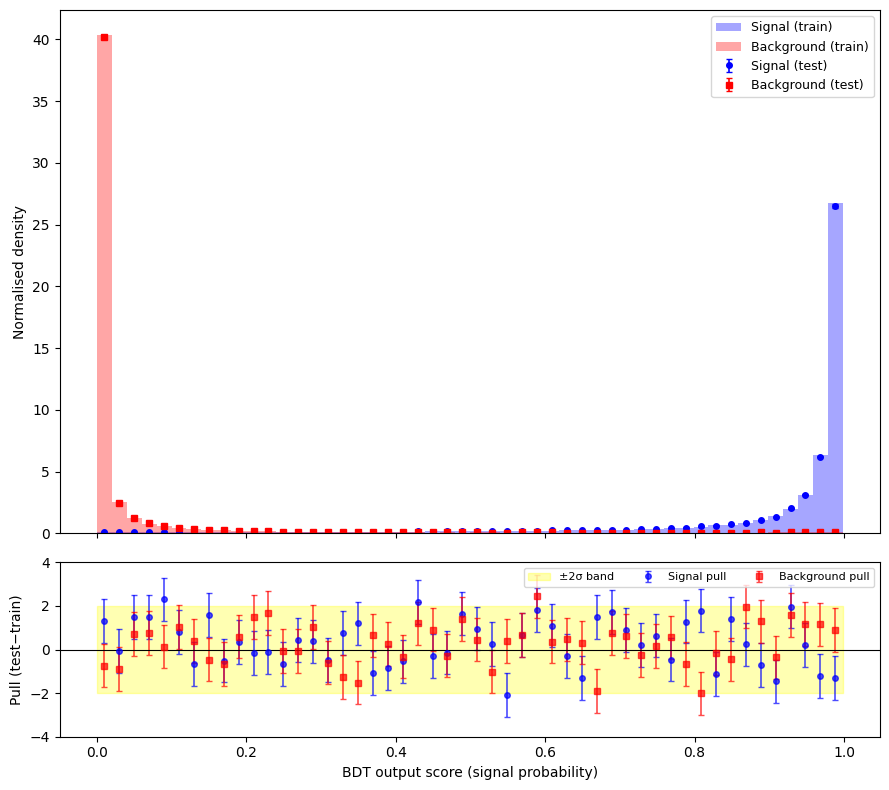

Overtraining check (train vs test):
  Signal:     KS = 0.0085,  p-value = 0.0087
  Background: KS = 0.0069,  p-value = 0.0577


In [25]:
# Compute BDT output scores for train and test (probability of signal class)
score_train = bdt.predict_proba(X_train)[:, 1]
score_test = bdt.predict_proba(X_test)[:, 1]

# Split by class
sig_train_scores = score_train[y_train == 1]
bkg_train_scores = score_train[y_train == 0]
sig_test_scores = score_test[y_test == 1]
bkg_test_scores = score_test[y_test == 0]

# Determine common bin range
all_scores = np.concatenate([score_train, score_test])
lo, hi = np.percentile(all_scores, [0.5, 99.5])
bins = np.linspace(lo, hi, 51)
centres = 0.5 * (bins[:-1] + bins[1:])
widths = np.diff(bins)

# --- Compute normalised densities and pulls for test vs train ---
def hist_density(arr, bins):
    counts, _ = np.histogram(arr, bins=bins)
    total = counts.sum()
    density = counts / (total * widths)
    err = np.sqrt(counts) / (total * widths)
    return density, err

sig_train_d, sig_train_e = hist_density(sig_train_scores, bins)
bkg_train_d, bkg_train_e = hist_density(bkg_train_scores, bins)
sig_test_d, sig_test_e = hist_density(sig_test_scores, bins)
bkg_test_d, bkg_test_e = hist_density(bkg_test_scores, bins)

# Pull = (test - train) / sqrt(err_test^2 + err_train^2)
def pull(test_d, test_e, train_d, train_e):
    combined_err = np.sqrt(test_e**2 + train_e**2)
    combined_err[combined_err == 0] = 1  # avoid division by zero
    return (test_d - train_d) / combined_err

sig_pull = pull(sig_test_d, sig_test_e, sig_train_d, sig_train_e)
bkg_pull = pull(bkg_test_d, bkg_test_e, bkg_train_d, bkg_train_e)

# --- Plot: main + pull panel ---
fig, (ax, ax_pull) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1]})

# Main panel: training as filled histograms, test as points
ax.hist(sig_train_scores, bins=bins, density=True, histtype="stepfilled",
        alpha=0.35, color="blue", label="Signal (train)")
ax.hist(bkg_train_scores, bins=bins, density=True, histtype="stepfilled",
        alpha=0.35, color="red", label="Background (train)")

ax.errorbar(centres, sig_test_d, yerr=sig_test_e, fmt="o", ms=4, color="blue",
            label="Signal (test)", capsize=2, lw=1.2)
ax.errorbar(centres, bkg_test_d, yerr=bkg_test_e, fmt="s", ms=4, color="red",
            label="Background (test)", capsize=2, lw=1.2)

ax.set_ylabel("Normalised density")
# ax.set_title("XGBoost classifier output — signal vs background (train/test comparison)")
ax.legend(loc="upper right", fontsize=9)

# Pull panel
ax_pull.errorbar(centres, sig_pull, yerr=1, fmt="o", ms=4, color="blue",
                 alpha=0.7, label="Signal pull", capsize=2, lw=1.2)
ax_pull.errorbar(centres, bkg_pull, yerr=1, fmt="s", ms=4, color="red",
                 alpha=0.7, label="Background pull", capsize=2, lw=1.2)
ax_pull.axhline(0, color="black", lw=0.8)
ax_pull.fill_between(bins[[0, -1]], -2, 2, color="yellow", alpha=0.3, label="±2σ band")
ax_pull.set_xlabel("BDT output score (signal probability)")
ax_pull.set_ylabel("Pull (test−train)")
ax_pull.set_ylim(-4, 4)
ax_pull.legend(fontsize=8, ncol=3, loc="upper right")

plt.tight_layout()
plt.show()

# KS test for overtraining check
ks_sig, p_sig = stats.ks_2samp(sig_train_scores, sig_test_scores)
ks_bkg, p_bkg = stats.ks_2samp(bkg_train_scores, bkg_test_scores)
print(f"Overtraining check (train vs test):")
print(f"  Signal:     KS = {ks_sig:.4f},  p-value = {p_sig:.4f}")
print(f"  Background: KS = {ks_bkg:.4f},  p-value = {p_bkg:.4f}")

## 2.6 Apply BDT to full data sample

Score every event in `data.root` with the trained classifier.

In [9]:
# Load full data sample (top 20 features + Bs_M)
data_full = data_tree.arrays(top20 + ["Bs_M"], library="np")
X_data = np.column_stack([data_full[col] for col in top20])
data_mass = data_full["Bs_M"]

# Score every data event (signal probability)
data_scores = bdt.predict_proba(X_data)[:, 1]
print(f"Scored {len(data_scores):,} data events")
print(f"Score range: [{data_scores.min():.3f}, {data_scores.max():.3f}]")
print(f"Score median: {np.median(data_scores):.3f}")

Scored 939,429 data events
Score range: [0.000, 0.999]
Score median: 0.006


## 2.7 Optimal BDT cut via $S/\sqrt{S+B}$

Scan classifier thresholds. For each cut, estimate $S$ and $B$ using sideband subtraction:
- **Signal window**: $5340 < m_{B_s} < 5400\;\text{MeV}$ (60 MeV)
- **Sidebands**: $[5150, 5300] \cup [5450, 5750]\;\text{MeV}$ (450 MeV total)
- $B = N_\text{sideband} \times 60/450$, $\;S = N_\text{window} - B$

Optimal BDT cut:  0.088
  S = 57518,  B = 15939
  S/sqrt(S+B) = 212.22


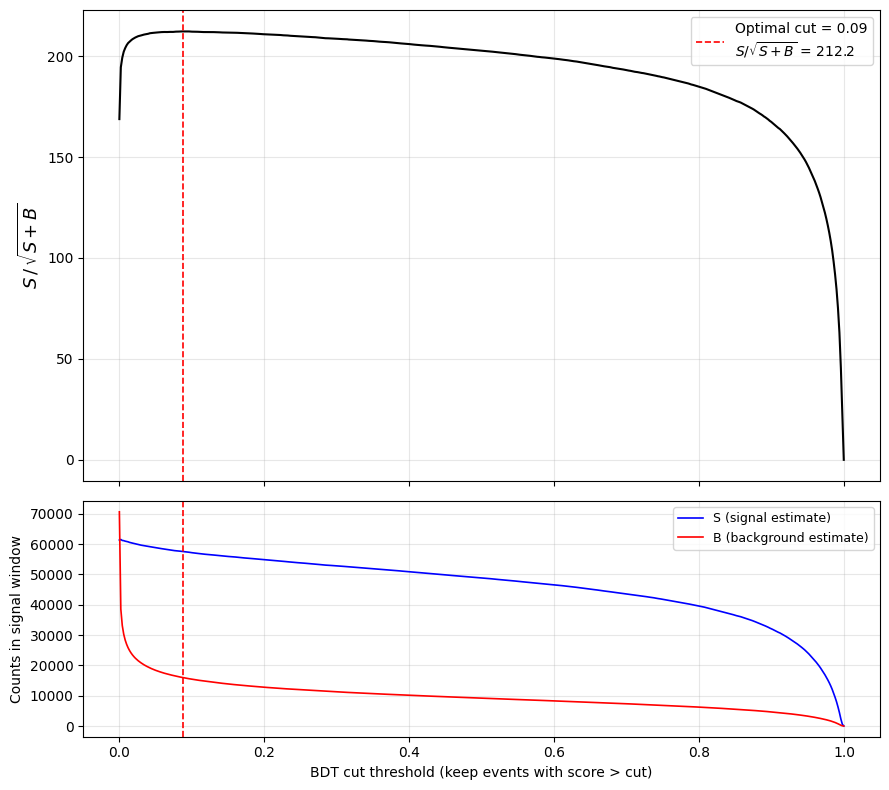

In [26]:
# Define mass regions
sig_lo, sig_hi = 5340, 5400  # signal window (60 MeV)
sb_ranges = [(5150, 5300), (5450, 5750)]  # sidebands (150 + 300 = 450 MeV)
sig_width = sig_hi - sig_lo  # 60
sb_width = sum(hi - lo for lo, hi in sb_ranges)  # 450
scale = sig_width / sb_width  # ratio to extrapolate sideband into signal window

# Masks for mass regions (applied to full data)
in_sig_window = (data_mass > sig_lo) & (data_mass < sig_hi)
in_sideband = np.zeros(len(data_mass), dtype=bool)
for lo, hi in sb_ranges:
    in_sideband |= (data_mass > lo) & (data_mass < hi)

# Scan BDT cut thresholds
cut_values = np.linspace(data_scores.min(), data_scores.max(), 500)
significance = []
S_vals = []
B_vals = []

for cut in cut_values:
    passes = data_scores > cut
    N_sig_window = np.sum(passes & in_sig_window)
    N_sideband = np.sum(passes & in_sideband)
    B = N_sideband * scale
    S = max(N_sig_window - B, 0)
    spb = S / np.sqrt(S + B) if (S + B) > 0 else 0
    significance.append(spb)
    S_vals.append(S)
    B_vals.append(B)

significance = np.array(significance)
S_vals = np.array(S_vals)
B_vals = np.array(B_vals)

# Optimal cut
best_idx = np.argmax(significance)
best_cut = cut_values[best_idx]
best_signif = significance[best_idx]
best_S = S_vals[best_idx]
best_B = B_vals[best_idx]

print(f"Optimal BDT cut:  {best_cut:.3f}")
print(f"  S = {best_S:.0f},  B = {best_B:.0f}")
print(f"  S/sqrt(S+B) = {best_signif:.2f}")

# Plot S/sqrt(S+B) vs BDT cut
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# Top: significance
ax1.plot(cut_values, significance, color="black", lw=1.5)
ax1.axvline(best_cut, color="red", ls="--", lw=1.2,
            label=f"Optimal cut = {best_cut:.2f}\n$S/\\sqrt{{S+B}}$ = {best_signif:.1f}")
ax1.set_ylabel(r"$S\,/\,\sqrt{S+B}$", fontsize=13)
# ax1.set_title(r"Significance scan — $S/\sqrt{S+B}$ vs BDT cut")
ax1.legend(fontsize=10, loc="upper right")
ax1.grid(alpha=0.3)

# Bottom: S and B counts
ax2.plot(cut_values, S_vals, color="blue", lw=1.2, label="S (signal estimate)")
ax2.plot(cut_values, B_vals, color="red", lw=1.2, label="B (background estimate)")
ax2.axvline(best_cut, color="red", ls="--", lw=1.2)
ax2.set_xlabel("BDT cut threshold (keep events with score > cut)")
ax2.set_ylabel("Counts in signal window")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

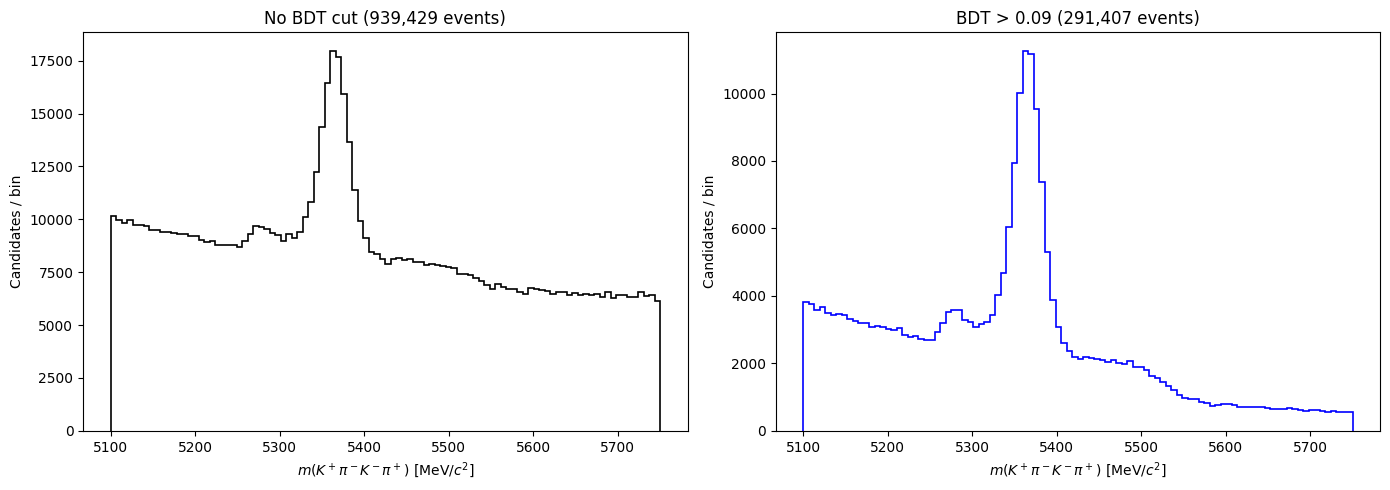

Optimal cut retains 291,407 / 939,429 events (31.0%)


In [27]:
# Show Bs mass at the optimal cut vs no cut
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data_mass, bins=100, range=(5100, 5750), histtype="step",
             color="black", lw=1.2)
axes[0].set_title(f"No BDT cut ({len(data_mass):,} events)")
axes[0].set_xlabel(r"$m(K^+\pi^-K^-\pi^+)$ [MeV/$c^2$]")
axes[0].set_ylabel("Candidates / bin")

opt_mask = data_scores > best_cut
axes[1].hist(data_mass[opt_mask], bins=100, range=(5100, 5750), histtype="step",
             color="blue", lw=1.2)
axes[1].set_title(f"BDT > {best_cut:.2f} ({opt_mask.sum():,} events)")
axes[1].set_xlabel(r"$m(K^+\pi^-K^-\pi^+)$ [MeV/$c^2$]")
axes[1].set_ylabel("Candidates / bin")

# plt.suptitle(r"$B_s^0$ mass — before vs after optimal BDT cut", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Optimal cut retains {opt_mask.sum():,} / {len(data_mass):,} events "
      f"({opt_mask.sum()/len(data_mass)*100:.1f}%)")

# Section 3: Reducing Other Backgrounds

After the BDT cut, three types of peaking background remain in the $m_{B_s}$ distribution:

1. **Misidentified decays** (e.g. $B_s^0 \to \phi K^{*0}$ where a kaon fakes a pion): produce peaks that can be identified via swapped-mass hypotheses and reduced with PID cuts and mass vetoes.
2. **$B^0 \to K^+\pi^-K^-\pi^+$** at ${\sim}5280\;\text{MeV}$: same final state as the signal, so PID cuts cannot help. Must be modelled as a separate Gaussian component in the mass fit (Section 4).
3. **Partially reconstructed decays** (e.g. $B_s \to D_s^- K^{*+}$, $B \to K^*K^*\pi$) at ${\sim}5100$–$5220\;\text{MeV}$: a soft particle is lost, shifting the mass below the $B$ peak. Cannot be cut away; modelled with an ARGUS or smeared step function in the mass fit (Section 4).

This section addresses type 1. Types 2 and 3 are handled in Section 4.

## 3.1 Apply BDT cut and inspect $m_{B_s}$

Events after BDT cut: 291,407


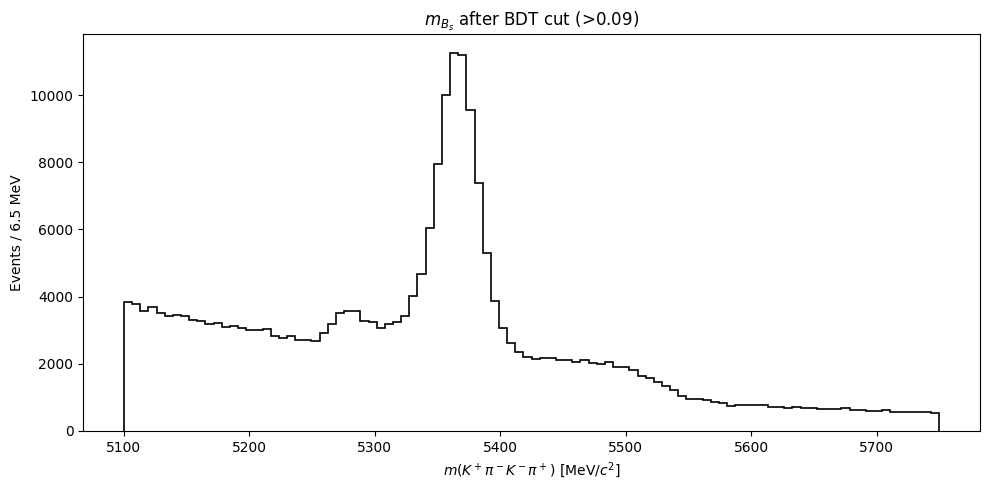

In [12]:
# Apply BDT cut from Section 2
bdt_mask = data_scores >= best_cut

# Load four-momenta for all final-state tracks
branches_4v = [
    "Kp_E", "Kp_PX", "Kp_PY", "Kp_PZ",
    "Km_E", "Km_PX", "Km_PY", "Km_PZ",
    "pip_E", "pip_PX", "pip_PY", "pip_PZ",
    "pim_E", "pim_PX", "pim_PY", "pim_PZ",
    "Kp_ProbNNk", "Km_ProbNNk", "pip_ProbNNpi", "pim_ProbNNpi",
    "Kp_ProbNNpi", "Km_ProbNNpi", "pip_ProbNNk", "pim_ProbNNk",
]
d = data_tree.arrays(branches_4v + ["Bs_M"], library="np")

# Helper: compute invariant mass from (E, px, py, pz) arrays
M_K = 493.677    # MeV/c^2
M_PI = 139.570
M_P = 938.272

def invmass(E, px, py, pz):
    """Invariant mass from summed 4-vectors."""
    return np.sqrt(np.maximum(E**2 - px**2 - py**2 - pz**2, 0))

def swap_mass(px, py, pz, new_m):
    """Recompute energy for a track under a new mass hypothesis."""
    return np.sqrt(px**2 + py**2 + pz**2 + new_m**2)

# Apply BDT cut to all arrays
sel = {k: v[bdt_mask] for k, v in d.items()}
mass_sel = sel["Bs_M"]
print(f"Events after BDT cut: {bdt_mask.sum():,}")

# Plot Bs_M after BDT cut — note any peaking structures
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mass_sel, bins=100, range=(5100, 5750), histtype="step", color="black", lw=1.2)
ax.set_xlabel(r"$m(K^+\pi^-K^-\pi^+)$ [MeV/$c^2$]")
ax.set_ylabel("Events / 6.5 MeV")
ax.set_title(f"$m_{{B_s}}$ after BDT cut (>{best_cut:.2f})")
plt.tight_layout()
plt.show()

## 3.2 Swapped-mass distributions

Recompute invariant masses under alternative mass hypotheses to identify misidentified backgrounds:
- $m(K^+, \pi^- \to K)$: $\phi \to K^+K^-$ from $B_s^0 \to \phi K^{*0}$
- $m(K^-, \pi^+ \to K)$: $\phi \to K^+K^-$ from $B_s^0 \to \phi \bar{K}^{*0}$
- $m(K^+ \to \pi, \pi^-)$: $\rho^0 / f_0 \to \pi^+\pi^-$ (double misID)
- $m(K^- \to \pi, \pi^+)$: same for the other $K^*$
- $m(\pi^- \to p)$ and $m(\pi^+ \to p)$: $\Lambda_b$ backgrounds

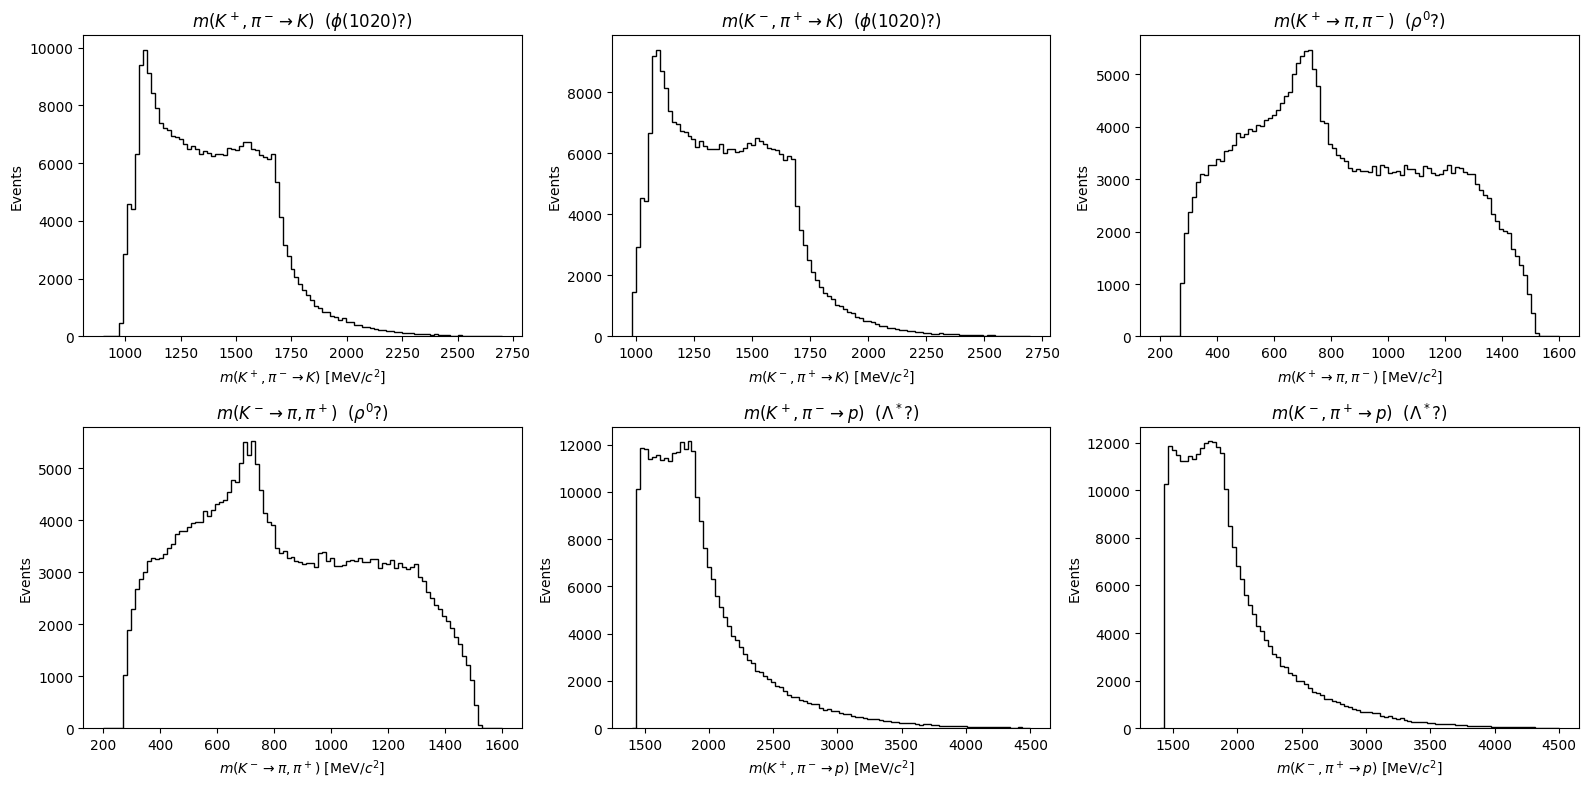

In [13]:
# Compute swapped-mass variables
# phi candidate: pim reassigned K mass, paired with Kp
pim_E_asK = swap_mass(sel["pim_PX"], sel["pim_PY"], sel["pim_PZ"], M_K)
m_Kp_pimAsK = invmass(sel["Kp_E"] + pim_E_asK,
                       sel["Kp_PX"] + sel["pim_PX"],
                       sel["Kp_PY"] + sel["pim_PY"],
                       sel["Kp_PZ"] + sel["pim_PZ"])

# phi candidate: pip reassigned K mass, paired with Km
pip_E_asK = swap_mass(sel["pip_PX"], sel["pip_PY"], sel["pip_PZ"], M_K)
m_Km_pipAsK = invmass(sel["Km_E"] + pip_E_asK,
                       sel["Km_PX"] + sel["pip_PX"],
                       sel["Km_PY"] + sel["pip_PY"],
                       sel["Km_PZ"] + sel["pip_PZ"])

# rho/f0 candidate: Kp reassigned pi mass, paired with pim
Kp_E_asPi = swap_mass(sel["Kp_PX"], sel["Kp_PY"], sel["Kp_PZ"], M_PI)
m_KpAsPi_pim = invmass(Kp_E_asPi + sel["pim_E"],
                        sel["Kp_PX"] + sel["pim_PX"],
                        sel["Kp_PY"] + sel["pim_PY"],
                        sel["Kp_PZ"] + sel["pim_PZ"])

# rho/f0 candidate: Km reassigned pi mass, paired with pip
Km_E_asPi = swap_mass(sel["Km_PX"], sel["Km_PY"], sel["Km_PZ"], M_PI)
m_KmAsPi_pip = invmass(Km_E_asPi + sel["pip_E"],
                        sel["Km_PX"] + sel["pip_PX"],
                        sel["Km_PY"] + sel["pip_PY"],
                        sel["Km_PZ"] + sel["pip_PZ"])

# Lambda_b candidate: pim reassigned proton mass
pim_E_asP = swap_mass(sel["pim_PX"], sel["pim_PY"], sel["pim_PZ"], M_P)
m_Kp_pimAsP = invmass(sel["Kp_E"] + pim_E_asP,
                       sel["Kp_PX"] + sel["pim_PX"],
                       sel["Kp_PY"] + sel["pim_PY"],
                       sel["Kp_PZ"] + sel["pim_PZ"])

# Lambda_b candidate: pip reassigned proton mass
pip_E_asP = swap_mass(sel["pip_PX"], sel["pip_PY"], sel["pip_PZ"], M_P)
m_Km_pipAsP = invmass(sel["Km_E"] + pip_E_asP,
                       sel["Km_PX"] + sel["pip_PX"],
                       sel["Km_PY"] + sel["pip_PY"],
                       sel["Km_PZ"] + sel["pip_PZ"])

# Plot all swapped-mass distributions
swap_specs = [
    (m_Kp_pimAsK,  r"$m(K^+, \pi^-{\to}K)$",  (900, 2700), r"$\phi(1020)$?"),
    (m_Km_pipAsK,  r"$m(K^-, \pi^+{\to}K)$",  (980, 2700), r"$\phi(1020)$?"),
    (m_KpAsPi_pim, r"$m(K^+{\to}\pi, \pi^-)$", (200, 1600), r"$\rho^0$?"),
    (m_KmAsPi_pip, r"$m(K^-{\to}\pi, \pi^+)$", (200, 1600), r"$\rho^0$?"),
    (m_Kp_pimAsP,  r"$m(K^+, \pi^-{\to}p)$",  (1400, 4500), r"$\Lambda^*$?"),
    (m_Km_pipAsP,  r"$m(K^-, \pi^+{\to}p)$",  (1400, 4500), r"$\Lambda^*$?"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (mass_arr, label, xrange, note) in zip(axes.flat, swap_specs):
    ax.hist(mass_arr, bins=100, range=xrange, histtype="step", color="black", lw=1)
    ax.set_xlabel(f"{label} [MeV/$c^2$]")
    ax.set_ylabel("Events")
    ax.set_title(f"{label}  ({note})")
plt.tight_layout()
plt.show()

## 3.3 PID cuts

The sideband $S/\sqrt{S+B}$ method from Section 2 is ineffective here: peaking backgrounds sit under the signal peak and are counted as "$S$" by the sideband subtraction. Instead, we optimise PID cuts by monitoring the $B^0$ peak region ($5250$–$5310\;\text{MeV}$) relative to the $B_s$ signal region ($5340$–$5400\;\text{MeV}$). A good PID cut should shrink the misID-fed $B^0$ shoulder without heavily eroding the $B_s$ peak.

We also scan the ratio $N_{B^0\,\text{region}} / N_{B_s\,\text{region}}$ as a function of PID threshold to find where the peaking contamination is minimised relative to signal.

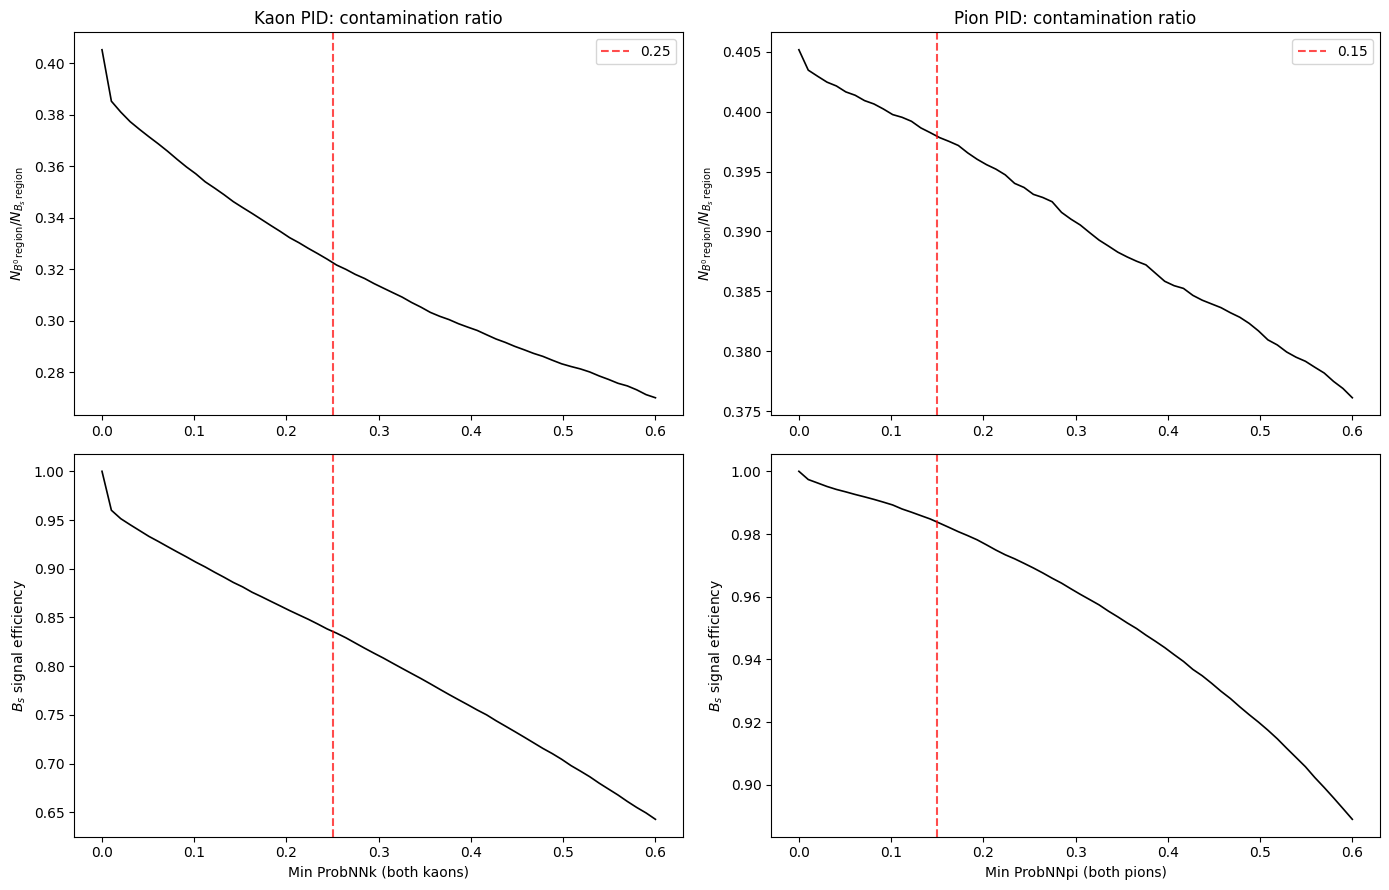

Chosen kaon PID cut:  ProbNNk  > 0.25
Chosen pion PID cut:  ProbNNpi > 0.15


In [14]:
# Scan PID cuts: monitor B0 peak region vs Bs signal region
Bd_lo, Bd_hi = 5250, 5310   # B0 peak region
Bs_lo, Bs_hi = 5340, 5400   # Bs signal region

pid_thresholds = np.linspace(0.0, 0.6, 60)

# Scan kaon PID
ratio_K = []
eff_K = []
n_Bs_nocut = np.sum((mass_sel > Bs_lo) & (mass_sel < Bs_hi))
for thr in pid_thresholds:
    k_mask = (sel["Kp_ProbNNk"] > thr) & (sel["Km_ProbNNk"] > thr)
    m = mass_sel[k_mask]
    n_Bd = np.sum((m > Bd_lo) & (m < Bd_hi))
    n_Bs = np.sum((m > Bs_lo) & (m < Bs_hi))
    ratio_K.append(n_Bd / n_Bs if n_Bs > 0 else np.nan)
    eff_K.append(n_Bs / n_Bs_nocut if n_Bs_nocut > 0 else 0)

# Scan pion PID
ratio_pi = []
eff_pi = []
for thr in pid_thresholds:
    pi_mask = (sel["pip_ProbNNpi"] > thr) & (sel["pim_ProbNNpi"] > thr)
    m = mass_sel[pi_mask]
    n_Bd = np.sum((m > Bd_lo) & (m < Bd_hi))
    n_Bs = np.sum((m > Bs_lo) & (m < Bs_hi))
    ratio_pi.append(n_Bd / n_Bs if n_Bs > 0 else np.nan)
    eff_pi.append(n_Bs / n_Bs_nocut if n_Bs_nocut > 0 else 0)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Kaon PID
axes[0, 0].plot(pid_thresholds, ratio_K, "k-", lw=1.2)
axes[0, 0].set_ylabel(r"$N_{B^0\,\mathrm{region}} / N_{B_s\,\mathrm{region}}$")
axes[0, 0].set_title("Kaon PID: contamination ratio")
axes[0, 0].axvline(0.25, color="red", ls="--", alpha=0.7, label="0.25")
axes[0, 0].legend()

axes[1, 0].plot(pid_thresholds, eff_K, "k-", lw=1.2)
axes[1, 0].set_xlabel("Min ProbNNk (both kaons)")
axes[1, 0].set_ylabel(r"$B_s$ signal efficiency")
axes[1, 0].axvline(0.25, color="red", ls="--", alpha=0.7)

# Pion PID
axes[0, 1].plot(pid_thresholds, ratio_pi, "k-", lw=1.2)
axes[0, 1].set_ylabel(r"$N_{B^0\,\mathrm{region}} / N_{B_s\,\mathrm{region}}$")
axes[0, 1].set_title("Pion PID: contamination ratio")
axes[0, 1].axvline(0.15, color="red", ls="--", alpha=0.7, label="0.15")
axes[0, 1].legend()

axes[1, 1].plot(pid_thresholds, eff_pi, "k-", lw=1.2)
axes[1, 1].set_xlabel("Min ProbNNpi (both pions)")
axes[1, 1].set_ylabel(r"$B_s$ signal efficiency")
axes[1, 1].axvline(0.15, color="red", ls="--", alpha=0.7)

plt.tight_layout()
plt.show()

# Choose working points — adjust after inspecting the plots above
best_K_thr = 0.25
best_pi_thr = 0.15
print(f"Chosen kaon PID cut:  ProbNNk  > {best_K_thr}")
print(f"Chosen pion PID cut:  ProbNNpi > {best_pi_thr}")

## 3.4 Apply PID cuts and mass vetoes

Apply the chosen PID thresholds and veto events with swapped-mass values near known resonances.

**Note:** The $B^0$ peak at ${\sim}5280\;\text{MeV}$ ($B^0 \to K^+\pi^-K^-\pi^+$, same final state) and the broad hump at ${\sim}5100$–$5220\;\text{MeV}$ (partially reconstructed decays) are **not** reducible by PID or mass vetoes. These are modelled as separate components in the mass fit (Section 4).

In [15]:
# Apply PID cuts
pid_mask = ((sel["Kp_ProbNNk"] > best_K_thr) &
            (sel["Km_ProbNNk"] > best_K_thr) &
            (sel["pip_ProbNNpi"] > best_pi_thr) &
            (sel["pim_ProbNNpi"] > best_pi_thr))

# Apply mass vetoes on swapped-mass variables where peaks were observed
# Adjust these windows after inspecting the 3.2 plots
phi_veto_lo, phi_veto_hi = 1005, 1035  # phi(1020) veto window [MeV]
veto_mask = ~(
    ((m_Kp_pimAsK > phi_veto_lo) & (m_Kp_pimAsK < phi_veto_hi)) |
    ((m_Km_pipAsK > phi_veto_lo) & (m_Km_pipAsK < phi_veto_hi))
)
# Add further vetoes here if 3.2 plots show additional peaks, e.g.:
# rho_veto_lo, rho_veto_hi = 740, 810
# veto_mask &= ~(
#     ((m_KpAsPi_pim > rho_veto_lo) & (m_KpAsPi_pim < rho_veto_hi)) |
#     ((m_KmAsPi_pip > rho_veto_lo) & (m_KmAsPi_pip < rho_veto_hi))
# )

all_cuts = pid_mask & veto_mask
print(f"PID cut:        {pid_mask.sum():,} events")
print(f"+ mass vetoes:  {all_cuts.sum():,} events")
print(f"Rejected:       {(~all_cuts).sum():,} events")

PID cut:        184,488 events
+ mass vetoes:  175,726 events
Rejected:       115,681 events


## 3.5 $m_{B_s}$ before and after peaking-background cuts

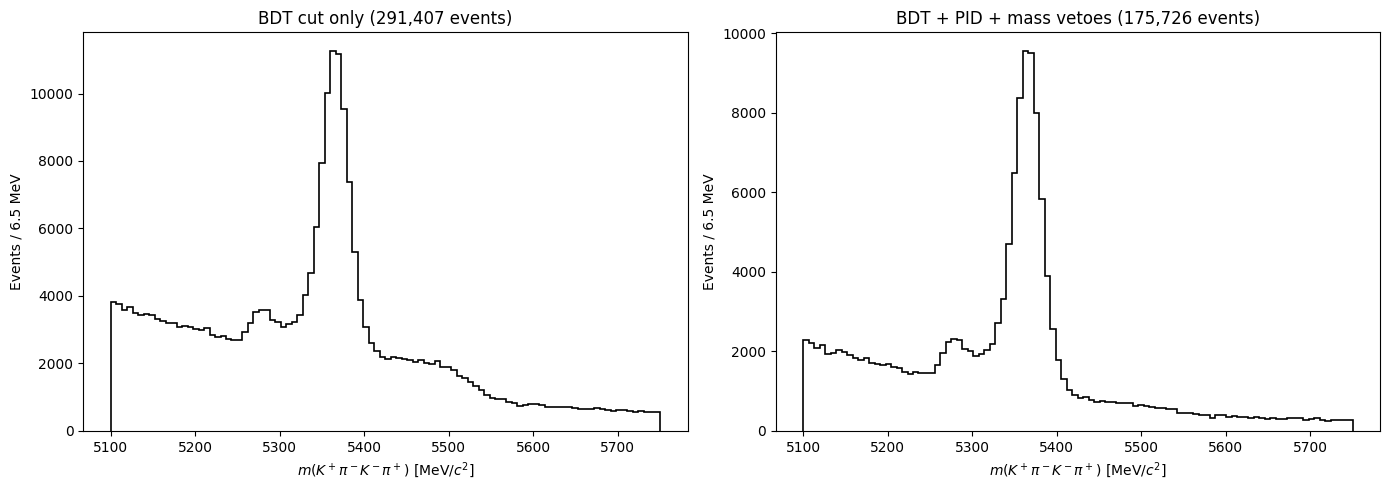

In [16]:
# Compare Bs mass: BDT cut only vs BDT + PID + mass vetoes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins, xrange = 100, (5100, 5750)

axes[0].hist(mass_sel, bins=bins, range=xrange, histtype="step", color="black", lw=1.2)
axes[0].set_title(f"BDT cut only ({len(mass_sel):,} events)")
axes[0].set_xlabel(r"$m(K^+\pi^-K^-\pi^+)$ [MeV/$c^2$]")
axes[0].set_ylabel("Events / 6.5 MeV")

mass_final = mass_sel[all_cuts]
axes[1].hist(mass_final, bins=bins, range=xrange, histtype="step", color="black", lw=1.2)
axes[1].set_title(f"BDT + PID + mass vetoes ({len(mass_final):,} events)")
axes[1].set_xlabel(r"$m(K^+\pi^-K^-\pi^+)$ [MeV/$c^2$]")
axes[1].set_ylabel("Events / 6.5 MeV")

plt.tight_layout()
plt.show()

# Section 4: $B$ Candidate Mass Fit

**Binned** extended maximum-likelihood fit to $m(K^+\pi^-K^-\pi^+)$ after all cuts, with three components:

1. **$B_s^0$ signal** — double Gaussian (shared mean $\mu_{B_s}$, core width $\sigma_1$, wide width $r\,\sigma_1$, fraction $f_\text{core}$)
2. **$B^0$ peak** — single Gaussian ($\mu_{B^0}$, width tied to $\sigma_1$)
3. **Combinatorial** — exponential $e^{\alpha m}$, $\alpha < 0$

Fit range: $5200$–$5750\;\text{MeV}$.

## 4.1 Define fit model

In [17]:
from iminuit import Minuit
from iminuit.cost import ExtendedBinnedNLL  # <-- CHANGED from BinnedNLL
from scipy.stats import norm as sp_norm

# Fit range and binning
fit_lo, fit_hi = 5200, 5750
n_bins = 130
fit_data = mass_final[(mass_final > fit_lo) & (mass_final < fit_hi)]
counts, bin_edges = np.histogram(fit_data, bins=n_bins, range=(fit_lo, fit_hi))
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]
n_total = counts.sum()
print(f"Events in fit range: {n_total:,}  |  {n_bins} bins of {bin_width:.1f} MeV")

# --- CDF components: each returns CDF values at edges (length = len(edges)) ---

def double_gaussian_cdf(edges, mu, sigma1, r_sigma, f_core):
    sigma2 = r_sigma * sigma1
    return f_core * sp_norm.cdf(edges, mu, sigma1) + (1 - f_core) * sp_norm.cdf(edges, mu, sigma2)

def gaussian_cdf(edges, mu, sigma):
    return sp_norm.cdf(edges, mu, sigma)

def exponential_cdf(edges, alpha):
    lo, hi = edges[0], edges[-1]
    if abs(alpha) < 1e-10:
        return (edges - lo) / (hi - lo)
    return (np.exp(alpha * edges) - np.exp(alpha * lo)) / \
           (np.exp(alpha * hi) - np.exp(alpha * lo))

# --- Model: ExtendedBinnedNLL expects f(edges, *params) -> CUMULATIVE EXPECTED COUNTS ---
def model_cdf(edges, n_Bs, mu_Bs, sigma1, r_sigma, f_core,
              n_Bd, mu_Bd,
              n_comb, alpha):
    cdf_Bs   = double_gaussian_cdf(edges, mu_Bs, sigma1, r_sigma, f_core)
    cdf_Bd   = gaussian_cdf(edges, mu_Bd, sigma1)
    cdf_comb = exponential_cdf(edges, alpha)
    return n_Bs * cdf_Bs + n_Bd * cdf_Bd + n_comb * cdf_comb

Events in fit range: 128,334  |  130 bins of 4.2 MeV


## 4.2 Run the fit

Initialise yields by eye from the histogram.

In [18]:
# Build EXTENDED binned NLL — model_cdf returns cumulative expected counts
cost = ExtendedBinnedNLL(counts, bin_edges, model_cdf)

mi = Minuit(cost,
    n_Bs=65000,      mu_Bs=5367,    sigma1=15,   r_sigma=2.5,  f_core=0.8,
    n_Bd=10000,      mu_Bd=5280,
    n_comb=40000,    alpha=-0.003,
)

# Parameter limits
mi.limits["n_Bs"]    = (0, 2 * n_total)
mi.limits["n_Bd"]    = (0, n_total)
mi.limits["n_comb"]  = (0, 2 * n_total)
mi.limits["mu_Bs"]   = (5350, 5390)
mi.limits["sigma1"]  = (5, 30)
mi.limits["r_sigma"] = (1.5, 5)
mi.limits["f_core"]  = (0.5, 1.0)
mi.limits["mu_Bd"]   = (5260, 5300)
mi.limits["alpha"]   = (-0.01, 0)

# Run MIGRAD + HESSE
mi.migrad()
mi.hesse()
print(mi)

if not mi.valid:
    print("WARNING: fit did not converge — check starting values and limits")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 589.2 (χ²/ndof = 4.9)      │              Nfcn = 513              │
│ EDM = 2.78e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───

## 4.3 Fit result: data with overlaid components + pull plot

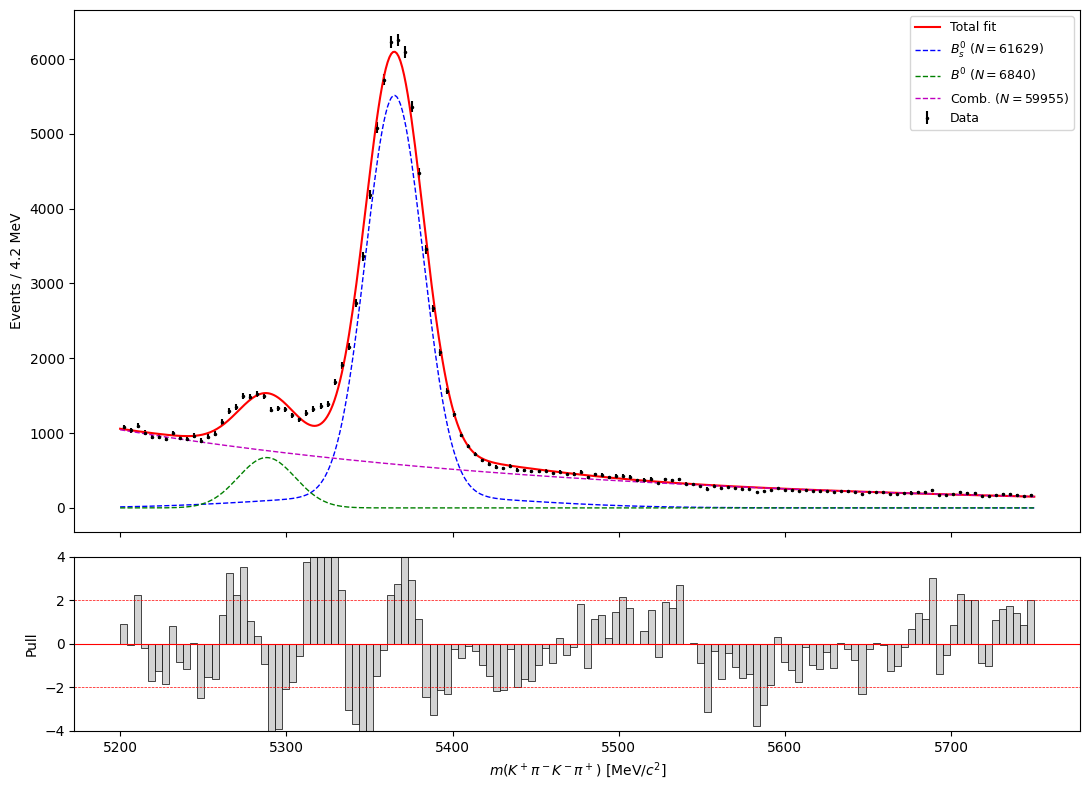


--- Fit results ---
  n_Bs         =  61628.830 ± 561.003
  mu_Bs        =   5365.016 ± 0.096
  sigma1       =     17.163 ± 0.122
  r_sigma      =      4.290 ± 0.316
  f_core       =      0.883 ± 0.009
  n_Bd         =   6840.350 ± 196.120
  mu_Bd        =   5288.150 ± 0.613
  n_comb       =  59955.465 ± 571.394
  alpha        =     -0.004 ± 0.000


In [19]:
# Extract fit parameters
p = mi.values

# Expected counts per bin via CDF differences
cdf_Bs   = double_gaussian_cdf(bin_edges, p["mu_Bs"], p["sigma1"], p["r_sigma"], p["f_core"])
cdf_Bd   = gaussian_cdf(bin_edges, p["mu_Bd"], p["sigma1"])
cdf_comb = exponential_cdf(bin_edges, p["alpha"])

b_Bs   = p["n_Bs"]   * np.diff(cdf_Bs)
b_Bd   = p["n_Bd"]   * np.diff(cdf_Bd)
b_comb = p["n_comb"] * np.diff(cdf_comb)
b_total = b_Bs + b_Bd + b_comb

# Smooth curves for overlay (PDF evaluated on fine grid, scaled to counts/bin)
m_plot = np.linspace(fit_lo, fit_hi, 500)
pdf_Bs = p["n_Bs"] * (p["f_core"] * sp_norm.pdf(m_plot, p["mu_Bs"], p["sigma1"]) +
         (1 - p["f_core"]) * sp_norm.pdf(m_plot, p["mu_Bs"], p["r_sigma"] * p["sigma1"])) * bin_width
pdf_Bd = p["n_Bd"] * sp_norm.pdf(m_plot, p["mu_Bd"], p["sigma1"]) * bin_width
a = p["alpha"]
if abs(a) > 1e-10:
    exp_norm = (np.exp(a * fit_hi) - np.exp(a * fit_lo)) / a
else:
    exp_norm = fit_hi - fit_lo
pdf_comb = p["n_comb"] * np.exp(a * m_plot) / exp_norm * bin_width

pdf_total = pdf_Bs + pdf_Bd + pdf_comb

# Pulls
with np.errstate(divide="ignore", invalid="ignore"):
    pulls = np.where(counts > 0, (counts - b_total) / np.sqrt(counts), 0)

# --- Plot ---
fig, (ax_main, ax_pull) = plt.subplots(2, 1, figsize=(11, 8),
    gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
fig.subplots_adjust(hspace=0.05)

ax_main.errorbar(bin_centres, counts, yerr=np.sqrt(np.maximum(counts, 1)),
                 fmt="k.", ms=3, capsize=0, label="Data")
ax_main.plot(m_plot, pdf_total, "r-", lw=1.5, label="Total fit")
ax_main.plot(m_plot, pdf_Bs,   "b--", lw=1, label=rf"$B_s^0$ ($N={p['n_Bs']:.0f}$)")
ax_main.plot(m_plot, pdf_Bd,   "g--", lw=1, label=rf"$B^0$ ($N={p['n_Bd']:.0f}$)")
ax_main.plot(m_plot, pdf_comb, "m--", lw=1, label=rf"Comb. ($N={p['n_comb']:.0f}$)")
ax_main.set_ylabel(f"Events / {bin_width:.1f} MeV")
ax_main.legend(fontsize=9, loc="upper right")
# ax_main.set_title(r"$B$ candidate mass fit")

# ax_pull.fill_between(bin_edges[:-1], 0, pulls,
#                      step="post", color="lightgray", edgecolor="black", linewidth=0.5)
ax_pull.bar(bin_centres, pulls, width=bin_width,
            color="lightgray", edgecolor="black", linewidth=0.5)
ax_pull.axhline(0, color="red", lw=0.8)
ax_pull.axhline(2, color="red", lw=0.5, ls="--")
ax_pull.axhline(-2, color="red", lw=0.5, ls="--")
ax_pull.set_xlabel(r"$m(K^+\pi^-K^-\pi^+)$ [MeV/$c^2$]")
ax_pull.set_ylabel("Pull")
ax_pull.set_ylim(-4, 4)

plt.tight_layout()
plt.show()

print(f"\n--- Fit results ---")
for name in ["n_Bs", "mu_Bs", "sigma1", "r_sigma", "f_core",
             "n_Bd", "mu_Bd", "n_comb", "alpha"]:
    print(f"  {name:12s} = {p[name]:10.3f} ± {mi.errors[name]:.3f}")

# Section 5: Projection of Signal in Intermediate Masses

In [21]:
# ---------- Compute sWeights from the mass fit ----------

# --- Per-event PDFs (normalised) for each component ---
def double_gaussian_pdf(m, mu, sigma1, r_sigma, f_core):
    sigma2 = r_sigma * sigma1
    return f_core * sp_norm.pdf(m, mu, sigma1) + (1 - f_core) * sp_norm.pdf(m, mu, sigma2)

def exponential_pdf(m, alpha, lo, hi):
    if abs(alpha) < 1e-10:
        return np.ones_like(m) / (hi - lo)
    return np.exp(alpha * m) * alpha / (np.exp(alpha * hi) - np.exp(alpha * lo))

# Evaluate PDFs at each event's Bs mass (only events in fit range)
p = mi.values
in_range = (mass_final > fit_lo) & (mass_final < fit_hi)
m_fit = mass_final[in_range]

f_Bs   = double_gaussian_pdf(m_fit, p["mu_Bs"], p["sigma1"], p["r_sigma"], p["f_core"])
f_Bd   = sp_norm.pdf(m_fit, p["mu_Bd"], p["sigma1"])  # single Gaussian, width tied to sigma1
f_comb = exponential_pdf(m_fit, p["alpha"], fit_lo, fit_hi)

N = np.array([p["n_Bs"], p["n_Bd"], p["n_comb"]])
f = np.column_stack([f_Bs, f_Bd, f_comb])  # shape (n_events, 3)

# Denominator: sum_n N_n * f_n(m) for each event
denom = f @ N  # shape (n_events,)

# sPlot covariance matrix V (inverse of the "S-matrix")
V_inv = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        V_inv[i, j] = np.sum(f[:, i] * f[:, j] / denom**2)
V = np.linalg.inv(V_inv)

# Signal sWeights: w_Bs(m) = sum_n V[0,n] * f_n(m) / denom(m)
sw_Bs = (V[0, :] @ f.T) / denom

print(f"Events in fit range: {len(m_fit):,}")
print(f"Sum of signal sWeights: {sw_Bs.sum():.0f}  (should ≈ n_Bs = {p['n_Bs']:.0f})")
print(f"sWeight range: [{sw_Bs.min():.2f}, {sw_Bs.max():.2f}]")

Events in fit range: 128,334
Sum of signal sWeights: 61629  (should ≈ n_Bs = 61629)
sWeight range: [-0.42, 1.20]


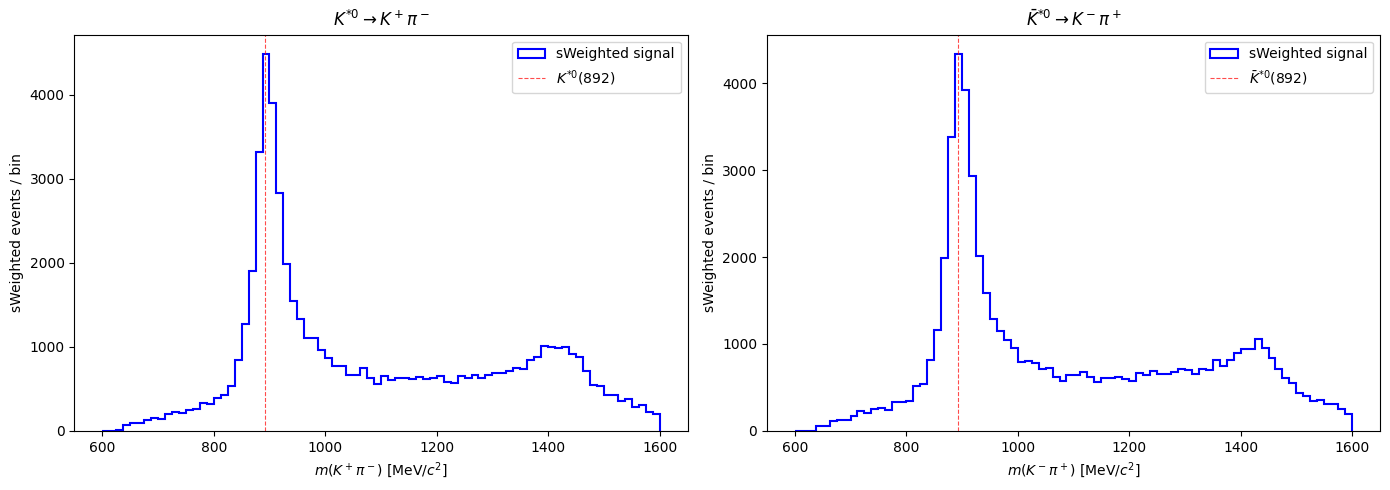

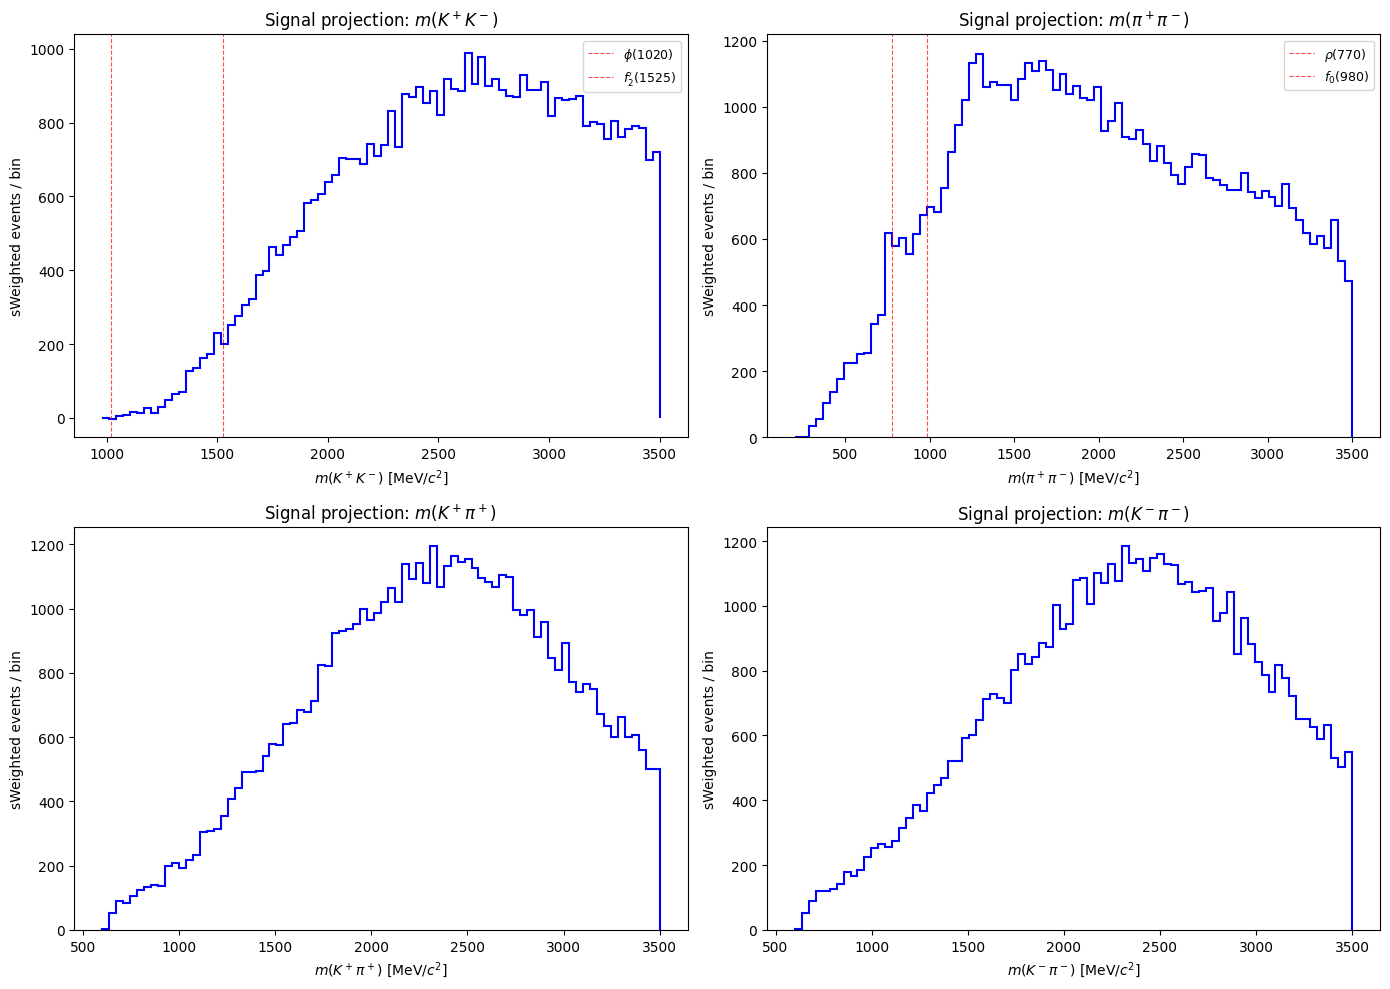

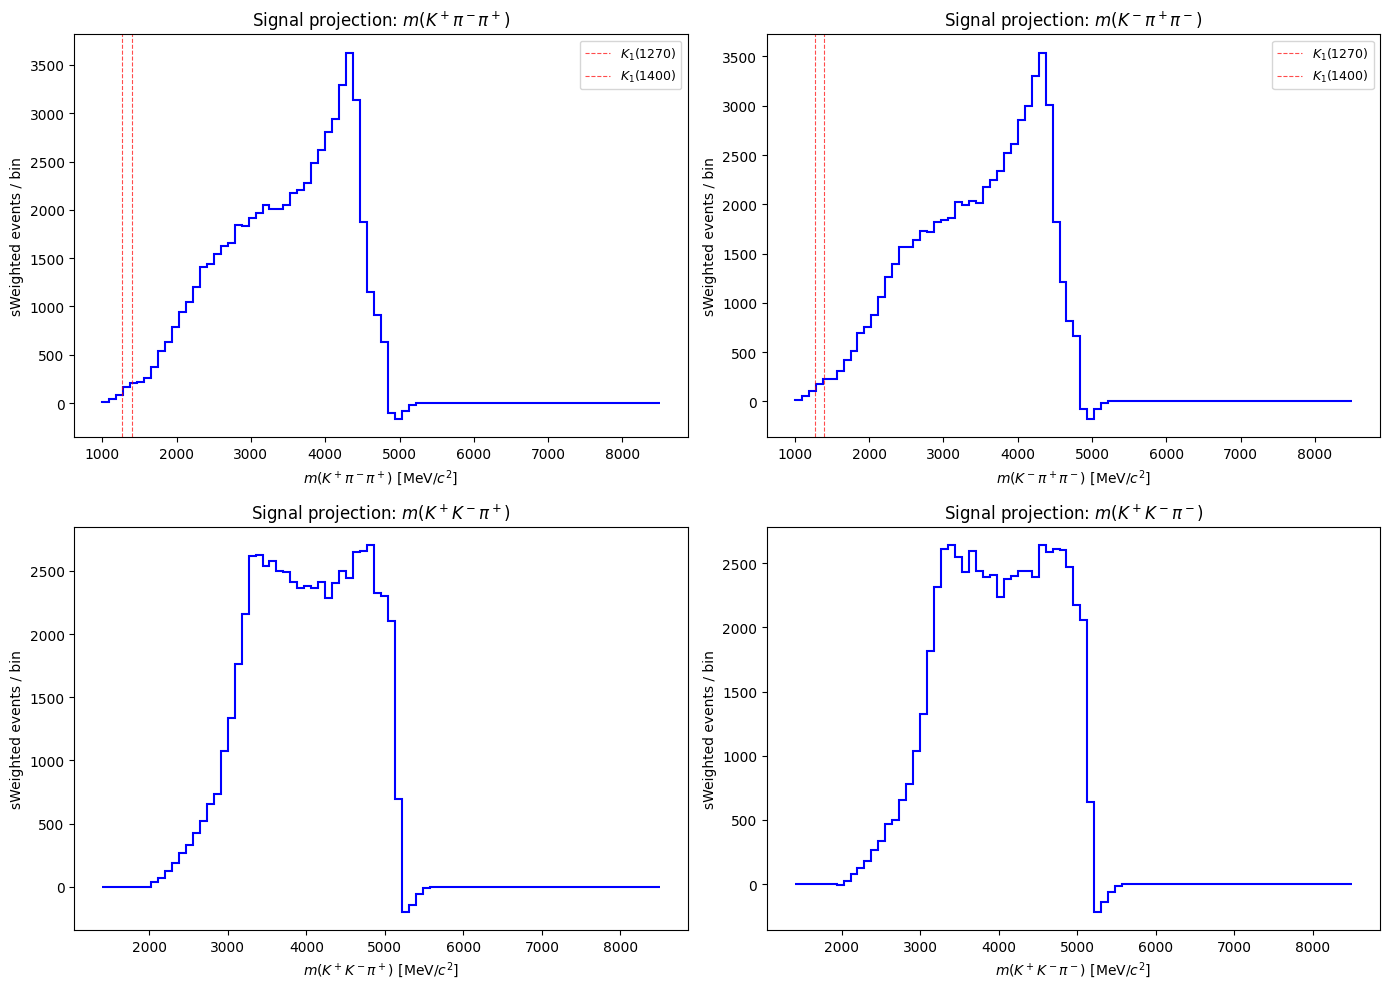

In [28]:
# ---------- Load Kpi invariant masses and plot sWeighted projections ----------

# Load the K*0 and K*0bar masses for events that passed all cuts
# (these are the "true hypothesis" Kpi masses from the ntuple)
kst_branches = ["Kst_M", "Kstb_M"]
d_kst = data_tree.arrays(kst_branches, library="np")

# Apply same selection chain: BDT -> PID + mass veto -> fit range
kst_m  = d_kst["Kst_M"][bdt_mask][all_cuts][in_range]
kstb_m = d_kst["Kstb_M"][bdt_mask][all_cuts][in_range]

# sWeighted histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mass_range = (600, 1600)
n_bins_kpi = 80

# K+pi- invariant mass (K*0)
axes[0].hist(kst_m, bins=n_bins_kpi, range=mass_range, weights=sw_Bs,
             histtype="step", color="blue", lw=1.5, label="sWeighted signal")
axes[0].axvline(892, color="red", ls="--", lw=0.8, alpha=0.7, label=r"$K^{*0}(892)$")
axes[0].set_xlabel(r"$m(K^+\pi^-)$ [MeV/$c^2$]")
axes[0].set_ylabel("sWeighted events / bin")
axes[0].set_title(r"$K^{*0} \to K^+\pi^-$")
axes[0].legend()

# K-pi+ invariant mass (K*0bar)
axes[1].hist(kstb_m, bins=n_bins_kpi, range=mass_range, weights=sw_Bs,
             histtype="step", color="blue", lw=1.5, label="sWeighted signal")
axes[1].axvline(892, color="red", ls="--", lw=0.8, alpha=0.7, label=r"$\bar{K}^{*0}(892)$")
axes[1].set_xlabel(r"$m(K^-\pi^+)$ [MeV/$c^2$]")
axes[1].set_ylabel("sWeighted events / bin")
axes[1].set_title(r"$\bar{K}^{*0} \to K^-\pi^+$")
axes[1].legend()

# plt.suptitle("Signal-projected invariant mass (sWeights)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ---------- Other 2-body and 3-body mass combinations ----------

# Load all four-momenta for events in final selection
branches_mom = [
    "Kp_E", "Kp_PX", "Kp_PY", "Kp_PZ",
    "Km_E", "Km_PX", "Km_PY", "Km_PZ",
    "pip_E", "pip_PX", "pip_PY", "pip_PZ",
    "pim_E", "pim_PX", "pim_PY", "pim_PZ",
]
d_mom = data_tree.arrays(branches_mom, library="np")

# Apply selection chain
sel_final = {k: v[bdt_mask][all_cuts][in_range] for k, v in d_mom.items()}

def invmass(particles):
    """Invariant mass from list of (E, px, py, pz) arrays."""
    E  = sum(p[0] for p in particles)
    px = sum(p[1] for p in particles)
    py = sum(p[2] for p in particles)
    pz = sum(p[3] for p in particles)
    return np.sqrt(np.maximum(E**2 - px**2 - py**2 - pz**2, 0))

# 4-vectors for each particle
Kp  = (sel_final["Kp_E"],  sel_final["Kp_PX"],  sel_final["Kp_PY"],  sel_final["Kp_PZ"])
Km  = (sel_final["Km_E"],  sel_final["Km_PX"],  sel_final["Km_PY"],  sel_final["Km_PZ"])
pip = (sel_final["pip_E"], sel_final["pip_PX"], sel_final["pip_PY"], sel_final["pip_PZ"])
pim = (sel_final["pim_E"], sel_final["pim_PX"], sel_final["pim_PY"], sel_final["pim_PZ"])

# --- 2-body combinations ---
m_KK       = invmass([Kp, Km])       # K+K-
m_pipi     = invmass([pip, pim])      # pi+pi-
m_Kp_pip   = invmass([Kp, pip])       # K+pi+ (same-sign)
m_Km_pim   = invmass([Km, pim])       # K-pi- (same-sign)

# --- 3-body combinations ---
m_Kp_pim_pip  = invmass([Kp, pim, pip])   # K+pi-pi+  (remove K-)
m_Km_pip_pim  = invmass([Km, pip, pim])   # K-pi+pi-  (remove K+)
m_Kp_Km_pip   = invmass([Kp, Km, pip])    # K+K-pi+   (remove pi-)
m_Kp_Km_pim   = invmass([Kp, Km, pim])    # K+K-pi-   (remove pi+)

# --- Plot 2-body ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

specs_2b = [
    (m_KK,      r"$m(K^+K^-)$",      (980, 3500),  axes[0, 0],
     [(1020, r"$\phi(1020)$"), (1525, r"$f_2'(1525)$")]),
    (m_pipi,    r"$m(\pi^+\pi^-)$",   (200, 3500),  axes[0, 1],
     [(775, r"$\rho(770)$"), (980, r"$f_0(980)$")]),
    (m_Kp_pip,  r"$m(K^+\pi^+)$",     (600, 3500),  axes[1, 0], []),
    (m_Km_pim,  r"$m(K^-\pi^-)$",     (600, 3500),  axes[1, 1], []),
]

for m_arr, label, xrange, ax, markers in specs_2b:
    ax.hist(m_arr, bins=80, range=xrange, weights=sw_Bs,
            histtype="step", color="blue", lw=1.5)
    for mval, mname in markers:
        ax.axvline(mval, color="red", ls="--", lw=0.8, alpha=0.7, label=mname)
    ax.set_xlabel(f"{label} [MeV/$c^2$]")
    ax.set_ylabel("sWeighted events / bin")
    ax.set_title(f"Signal projection: {label}")
    if markers:
        ax.legend(fontsize=9)

# plt.suptitle("2-body mass projections (sWeighted)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Plot 3-body ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

specs_3b = [
    (m_Kp_pim_pip, r"$m(K^+\pi^-\pi^+)$",  (1000, 8500), axes[0, 0],
     [(1270, r"$K_1(1270)$"), (1400, r"$K_1(1400)$")]),
    (m_Km_pip_pim, r"$m(K^-\pi^+\pi^-)$",   (1000, 8500), axes[0, 1],
     [(1270, r"$K_1(1270)$"), (1400, r"$K_1(1400)$")]),
    (m_Kp_Km_pip,  r"$m(K^+K^-\pi^+)$",     (1400, 8500), axes[1, 0],
     []),
    (m_Kp_Km_pim,  r"$m(K^+K^-\pi^-)$",     (1400, 8500), axes[1, 1],
     []),
]

for m_arr, label, xrange, ax, markers in specs_3b:
    ax.hist(m_arr, bins=80, range=xrange, weights=sw_Bs,
            histtype="step", color="blue", lw=1.5)
    for mval, mname in markers:
        ax.axvline(mval, color="red", ls="--", lw=0.8, alpha=0.7, label=mname)
    ax.set_xlabel(f"{label} [MeV/$c^2$]")
    ax.set_ylabel("sWeighted events / bin")
    ax.set_title(f"Signal projection: {label}")
    if markers:
        ax.legend(fontsize=9)

# plt.suptitle("3-body mass projections (sWeighted)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## Use of generative AI

Claude (Anthropic) was used to assist with code development and
report writing. All outputs were reviewed and tested by the author,
who takes full responsibility for the final submission.